<a href="https://colab.research.google.com/github/TienNguyen0712/customer-churn-data-mining/blob/main/notebooks/03_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🎯 **Problem Formulation (Định nghĩa mục tiêu)**

**Mục tiêu:** Mục tiêu của bài toán là xây dựng mô hình phân loại nhàm dự đoán khả năng rời bỏ của một khách hàng thông qua hợp đồng sử dụng, giá hợp đồng theo tháng, thời gian mà khách hàng đó trải nghiệm dịch vụ.

**Mục tiêu dự đoán:** Xác định các yếu tố ảnh hưởng mạnh đến khả năng rời bỏ của khách hàng, giảm chi phí để giữ chân hoặc loại bỏ một khách hàng

**Các mô hình được sử dụng:**
- Logistic Regression
  - Baseline-1: Tất cả đều không rời bỏ
  - Baseline-2: Tất cả đều không rời bỏ
  - Baseline-3: Thời gian dưới 6 tháng với nhãn rời bỏ
- Random Forest
- XGBoost

**Lý do lựa chọn mô hình được giải thích như sau:**
- Logistic Regression: Muốn chọn làm mô hình baseline giúp căn chỉnh ngưỡng sao cho tối ưu khả năng dự đoán rời bỏ cũng như suy nghĩ đến việc dự đoán khách hàng rời bỏ hoặc chấp nhận dự đoán sai khách hàng
- Random Forest: Xem các đặc trưng nào có yếu tố ảnh hưởng nhiều đến với tỷ lệ rời bỏ của một khách hàng
- XGBoost: Nâng cao hơn Random Forest giúp nhận ra nhiều yếu tố ảnh hưởng mà Random Forest không thể nhìn thấy

Mô hình được đánh giá dựa theo cac chỉ số **Precision, Recall, F1-Score, Accuracy** trong đó ưu tiên **Recall** vì giúp phát hiện dự đoán rời bỏ nhiều hơn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
telco = pd.read_csv('telco_customer.csv')
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## ⏫ **Data Prepocessing (Chuẩn bị dữ liệu)**

In [3]:
telco.info() # Kiểm tra kiểu dữ liệu từng đặc trưng

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
telco['SeniorCitizen'] = telco['SeniorCitizen'].astype('object')

## 🔀 **Train – Validation – Test Split (Chia tập huấn luyện và đánh giá)**

In [5]:
telco.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
drop_columns = ['gender', 'customerID', 'TotalCharges', 'Churn']

target = telco['Churn'].map({'No': 0, 'Yes': 1})

features = telco.drop(drop_columns, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 17), (1409, 17), (5634,), (1409,))

In [7]:
num_freatures = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = features.select_dtypes(include=['object']).columns.tolist()

print("Num features: ", num_freatures)
print("Cat features: ", cat_features)

Num features:  ['tenure', 'MonthlyCharges']
Cat features:  ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")) # Không sinh thứ tự giả, an toàn
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_freatures),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder="drop"
)

## 🤖 **Model Selection (Lựa chọn mô hình)**

In [9]:
logistic_regression = LogisticRegression(max_iter=1000, class_weight='balanced') # Thêm balancef để phạt nặng hơn khi dự đoán sai rời bỏ, nhằm tăng recall giảm acc

pipe_logistic_regression = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("classifier", logistic_regression)
])

In [10]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

pipe_random_forest = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("classifier", random_forest)
])

## 🏋️**Model Training (Huấn luyện mô hình)**

In [11]:
pipe_logistic_regression.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['SeniorCitizen', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [12]:
pipe_random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['SeniorCitizen', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

## 📊 **Model Evaluation (Đánh giá mô hình)**

              precision    recall  f1-score   support

           0       0.93      0.65      0.76      1035
           1       0.47      0.86      0.61       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.80      0.70      0.72      1409



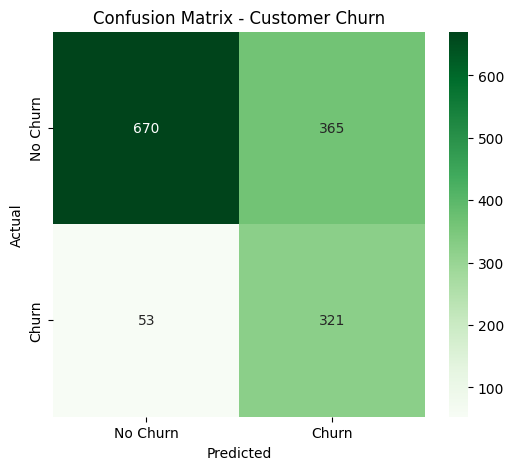

In [13]:
# Điều chính
y_pred_logistic_regression = pipe_logistic_regression.predict(X_test) # Dự đoán ngưỡng 0.5
y_proba_logistic_regression = pipe_logistic_regression.predict_proba(X_test)[:, 1]


# Thêm ngưỡng 0.4
threshold = 0.4
y_pred_logistic_regression_new = (y_proba_logistic_regression >= threshold).astype(int)

print(classification_report(y_test, y_pred_logistic_regression_new))

cm = confusion_matrix(y_test, y_pred_logistic_regression_new)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Customer Churn")
plt.show()

**Nhận xét**

- Chỉ số (Accuracy): **0.8** nhưng Recall: **0.56** thể hiện mô hình chỉ bắt được 56% khách hàng rời bỏ, 44% còn lại bị bỏ sót

Tức mô hình đang  dự đoán khá tốt nhóm không rời bỏ, nhưng lại bó sót khá nhiều nhóm rời bỏ

Nếu mục tiêu là giảm mất khách thì dây không phải là một mô hình tốt

- Sau khi tăng nặng việc phạt thì Recall tăng cho tháy mô hình bắt được 78& khách hàng rời bỏ, nhưng lại dự đoán nhiều khách hàng không trung thành hơn

- Tiếp tục tăng threshold giúp cho mô hình tăng dự đoán nhiều rời bỏ hơn nhừng đoán nhầm người  không churn là churn lại nhiều hơn

> Nếu đây là bài toán giảm chi phí doanh nghiệp thì mô hình tương đối tốt

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1035
           1       0.58      0.45      0.51       374

    accuracy                           0.77      1409
   macro avg       0.70      0.67      0.68      1409
weighted avg       0.75      0.77      0.76      1409



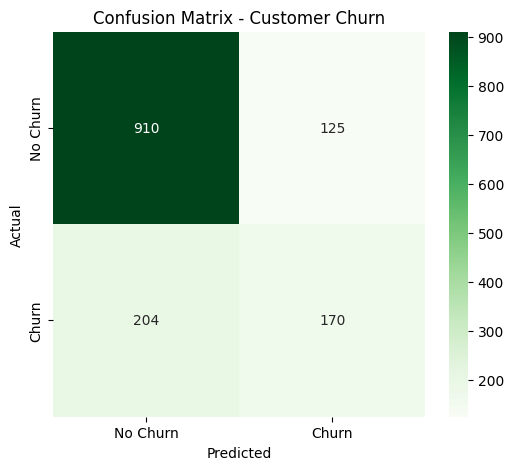

In [14]:
# Điều chính
y_pred_random_forest = pipe_random_forest.predict(X_test) # Dự đoán ngưỡng 0.5

print(classification_report(y_test, y_pred_random_forest))

cm = confusion_matrix(y_test, y_pred_random_forest)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Customer Churn")
plt.show()

**Nhận xét**

Recall kém hơn nên có thể kết luận rằng Random Forest hoạt động kém so với mô hình trên

## 🏆 **Model Comparison (So sánh mô hình)**

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "recall": "recall",
    "roc_auc": "roc_auc"
}

scores = cross_validate(
    pipe_logistic_regression,
    features,
    target,
    cv=skf,
    scoring=scoring
)

print("Logistic Regression")
print("Mean:", scores["test_recall"])
print("Mean Recall:", scores["test_recall"].mean())
print("Mean ROC-AUC:", scores["test_roc_auc"].mean())


Logistic Regression
Mean: [0.80481283 0.81818182 0.81016043 0.76407507 0.78074866]
Mean Recall: 0.7955957620679273
Mean ROC-AUC: 0.8430847121491863


**Nhận xét**

Mô hình ổn định Recall dao động từ 0.76 đến 0.82 cho thấy mô hình ổn định giữa các nhóm, không có fold nào bị quá khớp hay sau

So với testset thì với ngưỡng sâu 0.4 khá phù hợp

AUC cao cho thấy mô hình có khả năng phân biệt được khách hàng rời bỏ cao

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "recall": "recall",
    "roc_auc": "roc_auc"
}

scores = cross_validate(
    pipe_random_forest,
    features,
    target,
    cv=skf,
    scoring=scoring
)

print("Random Forest")
print("Mean:", scores["test_recall"])
print("Mean Recall:", scores["test_recall"].mean())
print("Mean ROC-AUC:", scores["test_roc_auc"].mean())


Random Forest
Mean: [0.51336898 0.52406417 0.5        0.41823056 0.44385027]
Mean Recall: 0.4799027970925149
Mean ROC-AUC: 0.8112068951993328


**Nhận xét**

Mô hình Random Forest kém hiệu quả hơn so với Logistic Regression một phần là do mô hình trên đã OneHot tuyến tính hoạt động tốt, bộ dữ liệu không quá phức tạp, nhiều không lớn

## ⚙️ **Hyperparameter Tuning (Tổi ưu hóa tham số)**

In [17]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"]
}

grid = GridSearchCV(
    pipe_logistic_regression,
    param_grid,
    cv=skf,
    scoring="roc_auc"
)

grid.fit(features, target)

print("Best params:", grid.best_params_)
print("Best AUC:", grid.best_score_)

Best params: {'classifier__C': 0.1, 'classifier__penalty': 'l2'}
Best AUC: 0.8432480451265405


## 🔎 **Feature Importance (Đặc trưng quan trọng)**

In [18]:
feature_names = pipe_logistic_regression.named_steps["preprocessor"].get_feature_names_out()
coefficients = pipe_logistic_regression.named_steps["classifier"].coef_[0]

import pandas as pd

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

print(coef_df.head(10))


                                Feature  Coefficient
14     cat__InternetService_Fiber optic     0.733836
34         cat__Contract_Month-to-month     0.659927
33             cat__StreamingMovies_Yes     0.294081
30                 cat__StreamingTV_Yes     0.283523
41  cat__PaymentMethod_Electronic check     0.233830
16               cat__OnlineSecurity_No     0.196062
25                  cat__TechSupport_No     0.159716
12               cat__MultipleLines_Yes     0.157533
24            cat__DeviceProtection_Yes     0.092586
38            cat__PaperlessBilling_Yes     0.075806


**Nhận xét**

Dựa theo hệ số tương quan dương lớn:

Khách hàng dùng Fiber có xác suất rời bỏ cao hơn

- Có thể giá cao
- Hoặc kỳ vọng cao -> dễ thất vọng
- Hoặc cạnh tranh mạnh ở phân khúc này

Khách hàng có hợp đồng tháng sẽ có xác suất rời bỏ cao

- Không ràng buộc
- Đổi chi phí thấp
- Dễ rời bỏ

Nhóm khách dùng dịch vụ giả trí có tỷ lệ rời bỏ cao hơn

- Combo giá cao
- Nhạy cảm với giá

Thanh toán điện tử liên quan rời bỏ cao

- Nhóm này trẻ
- Nhạy cảm giá
- Không bị ràng buộc tự động

Không có bảo vệ hoặc công nghệ hỗ trỡ sẽ có khả năng rời bỏ cao

- Khách thiêu hỗ trợ sẽ dễ rời bỏ khi có vấn đề

In [19]:
feature_names = pipe_logistic_regression.named_steps["preprocessor"].get_feature_names_out()
coefficients = pipe_logistic_regression.named_steps["classifier"].coef_[0]

import pandas as pd

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

print(coef_df.tail(10))


                                      Feature  Coefficient
17    cat__OnlineSecurity_No internet service    -0.274907
15                    cat__InternetService_No    -0.274907
32   cat__StreamingMovies_No internet service    -0.274907
29       cat__StreamingTV_No internet service    -0.274907
20      cat__OnlineBackup_No internet service    -0.274907
23  cat__DeviceProtection_No internet service    -0.274907
1                         num__MonthlyCharges    -0.570828
13                   cat__InternetService_DSL    -0.638903
0                                 num__tenure    -0.752865
36                     cat__Contract_Two year    -0.768431


**Nhận xét**

Hợp đồng 2 nằm làm giảm rời bỏ mạnh nhất

- Ràng buộc dài hạn -> Chi phí chuyển đổi cao
- Khách cam kết lâu dài
- Chiến lược hiệu quả

Ở lại càng lâu làm giảm rời bỏ

- Hiệu ứng trung thành
- Vượt qua giai đoạn thử ít rời bỏ

DSL thấp hơn Fiber

- Gía thấp
- Hoặc phân khúc khách khác

Chi phí cao liên quan đến rời bỏ giảm

- Tương tác với hợp đồng
- Có thể tồn tại ngoại lai hoặc nhiễu giữa phí theo tháng và hợp đồng

## 📝 **Conclusion (Kết luận)**

**Nhóm rủi ro cao**

1. Hợp đồng tháng
2. Fiber
3. Không có sercurity và tech
4. Thanh toán qua điện tử

**Nhóm ổn định**

1. Hợp đồng 2 năm
2. Tenure cao
3. DSL
4. Không dùng thiết bị internet

**Đề xuất**

Nên upsell nhằm kiếm nhiều giá trị. nên up cho nhóm chưa có online sercurity và tech đặc biệt với nhóm theo tháng và thời gian ở lại thấp (miễn phí 3 tháng bảo vệ cho nhóm có thể rời bỏ cao)



In [26]:
features.to_csv('features.csv', index=False)
target.to_csv('target.csv', index=False)